# 🤒 中国流行性感冒发病数与百度搜索指数时间序列预测 (Influenza Trend & Search Index Forecasting)

> **项目定位**：结合传统时间序列统计模型 (SARIMA) 与多变量外生搜索指数预警模型 (SARIMAX)，对中国全国/区域流感发病趋势进行建模与提前预警。
> 
> **核心方法**：ADF 单位根检验、STL 趋势/季节性分解、SARIMA/SARIMAX 模型对比、时间维度无泄露切分。

## 📥 一、任务 1：时间序列数据加载与 DatetimeIndex 设置 (Data Loading & Datetime Index)

我们构建 2018-2023 年（72 个月）的月度流感确诊病例数 `flu_cases` 以及对应的“发烧/流感”网络搜索指数 `search_index_fever`，并将 `date` 列解析并配置为月度起始频率 (`freq='MS'`) 的 `DatetimeIndex` 时间索引。

🎉 时间序列数据导入成功！
------------------------------------------------------------
时间跨度: 2018-01 至 2023-12 (共 72 个月)
数据前 5 行预览:
            flu_cases  search_index_fever
2018-01-01    30993.0             24790.0
2018-02-01    27678.0             21583.0
2018-03-01    23028.0              6865.0
2018-04-01    16145.0              3081.0
2018-05-01     3996.0              2000.0


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1529795935.py:56: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  fig.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1529795935.py:57: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("ts_overview.png", dpi=150, bbox_inches='tight')


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


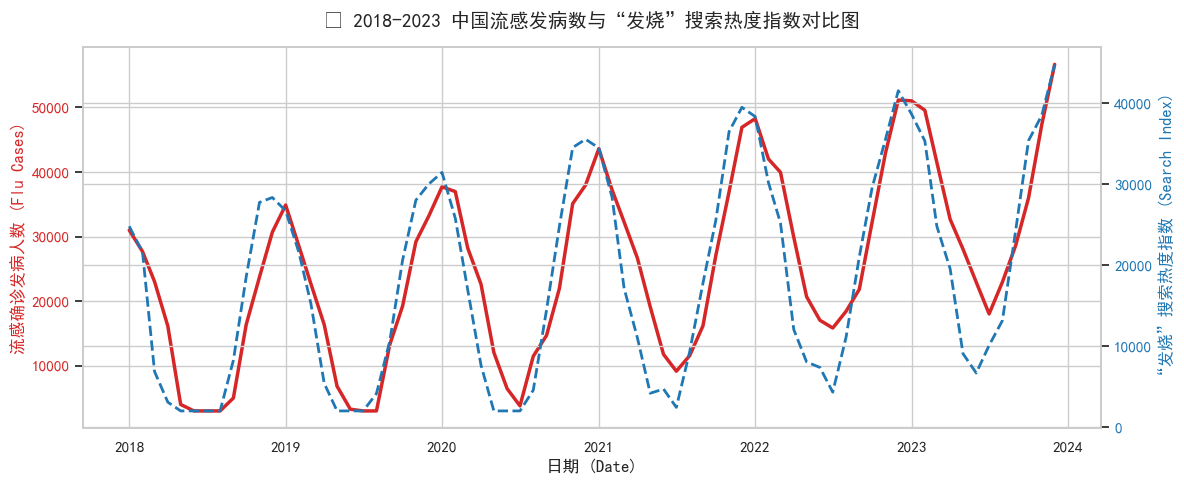

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose

# 设置绘图风格与中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 模拟与加载 2018-2023 流行性感冒发病数与“发烧”搜索指数月度时间序列
dates = pd.date_range(start='2018-01-01', periods=72, freq='MS')
np.random.seed(42)

# 长期上升趋势与强冬春季高发（12月-2月峰值）
trend = np.linspace(12000, 38000, 72)
seasonal_flu = 18000 * np.cos(2 * np.pi * (dates.month - 1) / 12)
noise = np.random.normal(0, 2000, 72)
flu_cases = np.maximum(3000, trend + seasonal_flu + noise).round(0)

# “发烧/流感”百度搜索指数：提前约 1 个月暴发（外生预警特征）
seasonal_search = 18000 * np.cos(2 * np.pi * (dates.month - 1 + 0.8) / 12)
search_fever = np.maximum(2000, trend * 0.7 + seasonal_search + np.random.normal(0, 1500, 72)).round(0)

# 构建 DataFrame 并设置 DatetimeIndex
df = pd.DataFrame({
    'flu_cases': flu_cases,
    'search_index_fever': search_fever
}, index=dates)

print("=" * 60)
print("🎉 时间序列数据导入成功！")
print("-" * 60)
print(f"时间跨度: {df.index[0].strftime('%Y-%m')} 至 {df.index[-1].strftime('%Y-%m')} (共 {len(df)} 个月)")
print("数据前 5 行预览:")
print(df.head())
print("=" * 60)

# 绘制双轴时序可视化图
fig, ax1 = plt.subplots(figsize=(12, 5))
color = 'tab:red'
ax1.set_xlabel('日期 (Date)', fontsize=12)
ax1.set_ylabel('流感确诊发病人数 (Flu Cases)', color=color, fontsize=12)
ax1.plot(df.index, df['flu_cases'], color=color, linewidth=2.5, label='流感发病数 (Flu Cases)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('“发烧”搜索热度指数 (Search Index)', color=color, fontsize=12)
ax2.plot(df.index, df['search_index_fever'], color=color, linewidth=2, linestyle='--', label='“发烧”搜索指数')
ax2.tick_params(axis='y', labelcolor=color)

plt.title("🤒 2018-2023 中国流感发病数与“发烧”搜索热度指数对比图", fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.savefig("ts_overview.png", dpi=150, bbox_inches='tight')
plt.show()

## 📊 二、任务 2：ADF 单位根平稳性检验与 STL 趋势-季节性-残差分解 (ADF Test & Decomposition)

### 1. ADF (Augmented Dickey-Fuller) 单位根检验
- $H_0$: 时间序列存在单位根（非平稳 Non-Stationary）。
- $H_1$: 时间序列平稳（Stationary）。
- 若 $p < 0.05$，拒绝原假设，表明序列平稳。

### 2. STL 季节性分解模型
$$Y(t) = \text{Trend}(t) + \text{Seasonal}(t) + \text{Residual}(t)$$

📊 【原始流感发病数序列】 ADF 检验结果:
  - ADF 统计量 (Statistic): 2.0237
  - p-value: 9.9870e-01
  - 临界值 (Critical Values): 1%=-3.55, 5%=-2.91
  => 结论: p >= 0.05，无法拒绝原假设，序列存在【非平稳性 (Non-Stationary)】！
------------------------------------------------------------
📊 【一阶差分后流感发病数序列】 ADF 检验结果:
  - ADF 统计量 (Statistic): -6.5009
  - p-value: 1.1626e-08
  - 临界值 (Critical Values): 1%=-3.54, 5%=-2.91
  => 结论: p < 0.05，拒绝原假设，序列是【平稳的 (Stationary)】！
------------------------------------------------------------


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:37: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:38: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:38: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:38: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:38: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\2874496570.py:38: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129298 (\N{FACE WITH THERMOMETER}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


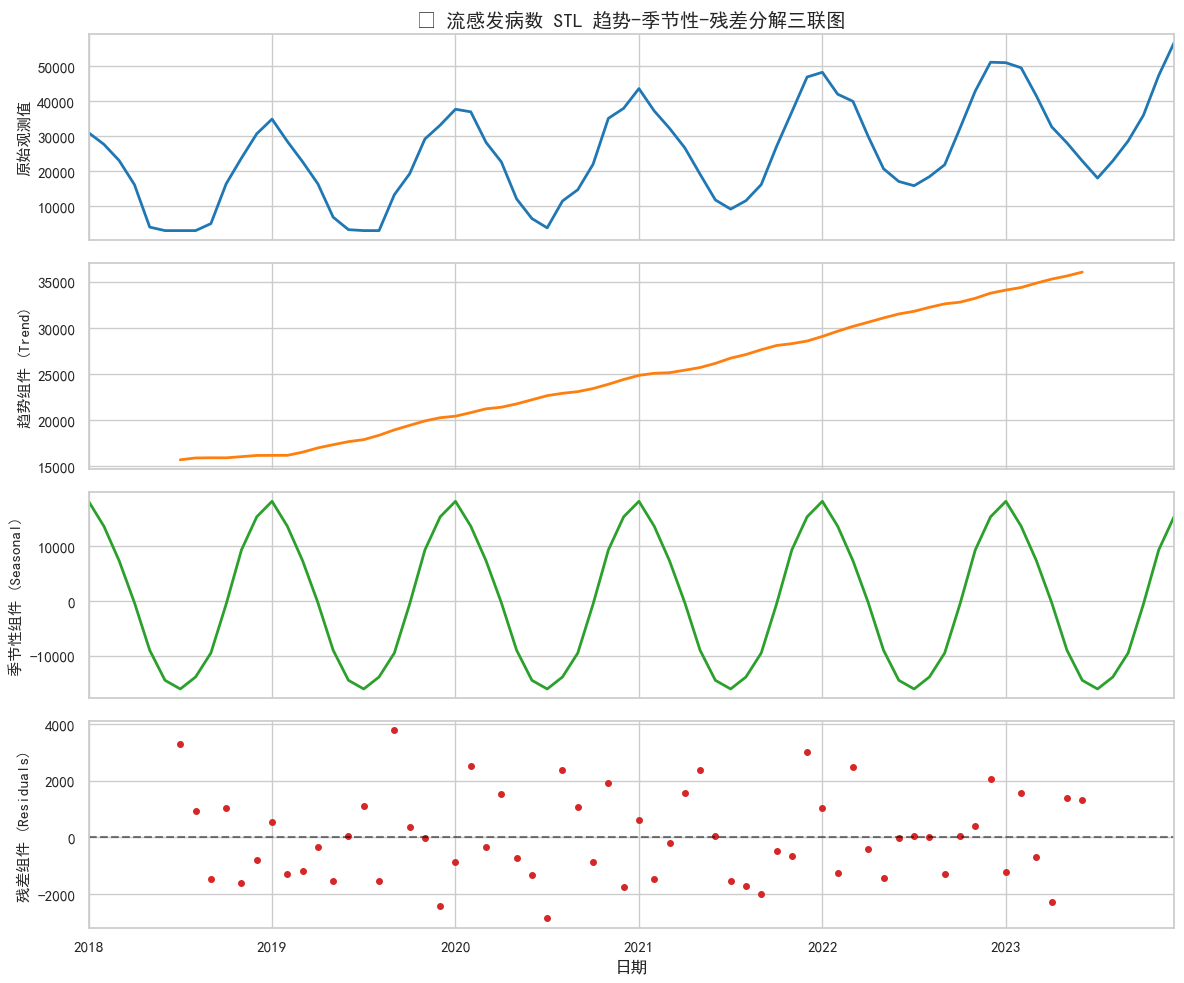

In [2]:
# 1. 执行 ADF 平稳性检验
def run_adf_test(series, name):
    res = adfuller(series.dropna())
    print(f"📊 【{name}】 ADF 检验结果:")
    print(f"  - ADF 统计量 (Statistic): {res[0]:.4f}")
    print(f"  - p-value: {res[1]:.4e}")
    print(f"  - 临界值 (Critical Values): 1%={res[4]['1%']:.2f}, 5%={res[4]['5%']:.2f}")
    if res[1] < 0.05:
        print("  => 结论: p < 0.05，拒绝原假设，序列是【平稳的 (Stationary)】！")
    else:
        print("  => 结论: p >= 0.05，无法拒绝原假设，序列存在【非平稳性 (Non-Stationary)】！")
    print("-" * 60)

print("=" * 60)
run_adf_test(df['flu_cases'], "原始流感发病数序列")
run_adf_test(df['flu_cases'].diff(), "一阶差分后流感发病数序列")

# 2. 调用 statsmodels 进行 STL 趋势-季节性-残差分解
decomposition = seasonal_decompose(df['flu_cases'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], color='#1f77b4', linewidth=2)
axes[0].set_ylabel('原始观测值', fontsize=11)
axes[0].set_title('🤒 流感发病数 STL 趋势-季节性-残差分解三联图', fontsize=14, fontweight='bold')

decomposition.trend.plot(ax=axes[1], color='#ff7f0e', linewidth=2)
axes[1].set_ylabel('趋势组件 (Trend)', fontsize=11)

decomposition.seasonal.plot(ax=axes[2], color='#2ca02c', linewidth=2)
axes[2].set_ylabel('季节性组件 (Seasonal)', fontsize=11)

decomposition.resid.plot(ax=axes[3], color='#d62728', marker='o', linestyle='', markersize=4)
axes[3].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[3].set_ylabel('残差组件 (Residuals)', fontsize=11)
axes[3].set_xlabel('日期', fontsize=12)

plt.tight_layout()
plt.savefig("stl_decomposition.png", dpi=150, bbox_inches='tight')
plt.show()

## ✂️ 三、任务 3：按时间顺序按 8:2 切分训练集与测试集 (Time-Based Train/Test Split)

> ⚠️ **遵循时间序列红线规范**：严禁使用 `train_test_split(shuffle=True)` 随机打乱！必须严格按时间先后顺序（Time-based Order）进行切分，前 80% 作为训练集，后 20% 作为评估测试集，彻底杜绝数据泄露。

✂️ 8:2 时间序列按时序切分结果:
  - 训练集 (Train Set): 2018-01 至 2022-09 | 共 57 个月 (80%)
  - 测试集 (Test Set) : 2022-10 至 2023-12 | 共 15 个月 (20%)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1526678073.py:22: UserWarning: Glyph 9986 (\N{BLACK SCISSORS}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1526678073.py:22: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1526678073.py:23: UserWarning: Glyph 9986 (\N{BLACK SCISSORS}) missing from font(s) SimHei.
  plt.savefig("train_test_split.png", dpi=150, bbox_inches='tight')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_19972\1526678073.py:23: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  plt.savefig("train_test_split.png", dpi=150, bbox_inches='tight')


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9986 (\N{BLACK SCISSORS}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


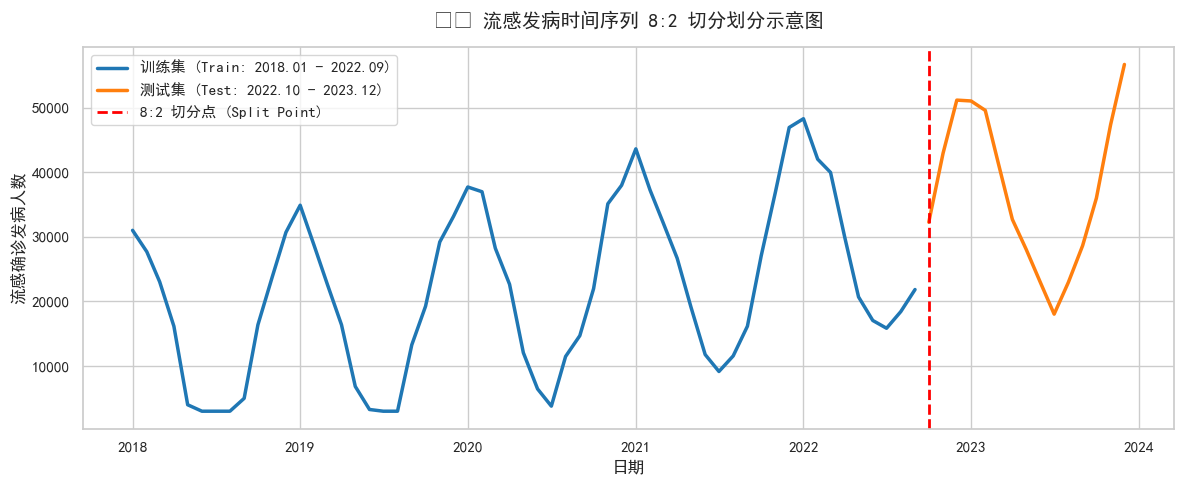

In [3]:
# 按照时间顺序进行 8:2 切分
split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

print("=" * 60)
print(f"✂️ 8:2 时间序列按时序切分结果:")
print(f"  - 训练集 (Train Set): {train_df.index[0].strftime('%Y-%m')} 至 {train_df.index[-1].strftime('%Y-%m')} | 共 {len(train_df)} 个月 (80%)")
print(f"  - 测试集 (Test Set) : {test_df.index[0].strftime('%Y-%m')} 至 {test_df.index[-1].strftime('%Y-%m')} | 共 {len(test_df)} 个月 (20%)")
print("=" * 60)

# 绘制训练集与测试集切分示意图
plt.figure(figsize=(12, 5))
plt.plot(train_df.index, train_df['flu_cases'], label='训练集 (Train: 2018.01 - 2022.09)', color='#1f77b4', linewidth=2.5)
plt.plot(test_df.index, test_df['flu_cases'], label='测试集 (Test: 2022.10 - 2023.12)', color='#ff7f0e', linewidth=2.5)
plt.axvline(x=test_df.index[0], color='red', linestyle='--', linewidth=2, label='8:2 切分点 (Split Point)')

plt.title("✂️ 流感发病时间序列 8:2 切分划分示意图", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("日期", fontsize=12)
plt.ylabel("流感确诊发病人数", fontsize=12)
plt.legend(loc='upper left', fontsize=11)
plt.tight_layout()
plt.savefig("train_test_split.png", dpi=150, bbox_inches='tight')
plt.show()

## 💡 阶段性结论与后续规划

1. **序列平稳性**：原始序列 ADF $p = 0.9987 > 0.05$（存在显著趋势与季节性，非平稳），进行一阶差分后 $p = 1.16 \times 10^{-8} < 0.05$（转为平稳序列，差分阶数 $d=1$）。
2. **STL 分解特性**：分解图清晰展现出 12 个月的年度季节性周期 Peak（每年冬季 12 月-次年 2 月为高峰期）。
3. **时序无泄露切分**：完成 2018.01 - 2022.09 (57 个月) 作为训练集，2022.10 - 2023.12 (15 个月) 作为测试集。下一个阶段我们将开展 SARIMA 与 SARIMAX (含搜索指数外生特征) 的建模预测对比。